<a href="https://colab.research.google.com/github/SahuUsha/Sentiment-and-Analysis-/blob/main/Sentiment_and_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, GRU, Dropout, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
path = kagglehub.dataset_download("bhavikjikadara/imdb-dataset-sentiment-analysis")

files = os.listdir(path)
df = pd.read_csv(os.path.join(path, files[0]))

df.head()

100%|██████████| 25.7M/25.7M [00:00<00:00, 64.1MB/s]

Extracting files...


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

df['review'] = df['review'].apply(clean_text)

In [4]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

X = df['review']
y = df['sentiment']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
max_words = 17000
max_len = 300

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [7]:
model_dense = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    GlobalAveragePooling1D(), # Added pooling layer
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_dense.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'Precision', 'Recall']
)

early_stop = EarlyStopping(monitor='val_loss', patience=2)

start = time.time()

history_dense = model_dense.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

end = time.time()
print("Dense Training Time:", end - start)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - Precision: 0.7536 - Recall: 0.7586 - accuracy: 0.7559 - loss: 0.4862 - val_Precision: 0.8426 - val_Recall: 0.9130 - val_accuracy: 0.8712 - val_loss: 0.3128
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Precision: 0.8811 - Recall: 0.8826 - accuracy: 0.8820 - loss: 0.2873 - val_Precision: 0.8521 - val_Recall: 0.9330 - val_accuracy: 0.8855 - val_loss: 0.2821
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Precision: 0.9049 - Recall: 0.9085 - accuracy: 0.9068 - loss: 0.2326 - val_Precision: 0.9353 - val_Recall: 0.6290 - val_accuracy: 0.7928 - val_loss: 0.4285
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Precision: 0.9248 - Recall: 0.9264 - accuracy: 0.9257 - loss: 0.1987 - val_Precision: 0.8239 - val_Recall: 0.9438 - val_accuracy: 0.8710 - val_loss: 0.3325
Dense Training Time: 12.953237533569336


In [8]:
model_lstm = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(128),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'Precision', 'Recall']
)

start = time.time()

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

end = time.time()
print("LSTM Training Time:", end - start)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - Precision: 0.7893 - Recall: 0.8093 - accuracy: 0.7971 - loss: 0.4392 - val_Precision: 0.8323 - val_Recall: 0.9085 - val_accuracy: 0.8627 - val_loss: 0.3294
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - Precision: 0.9008 - Recall: 0.9053 - accuracy: 0.9030 - loss: 0.2564 - val_Precision: 0.8875 - val_Recall: 0.8597 - val_accuracy: 0.8754 - val_loss: 0.2982
LSTM Training Time: 24.915741205215454


In [9]:
model_gru = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    GRU(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_gru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'Precision', 'Recall']
)

start = time.time()

history_gru = model_gru.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

end = time.time()
print("GRU Training Time:", end - start)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - Precision: 0.7986 - Recall: 0.8030 - accuracy: 0.8007 - loss: 0.4270 - val_Precision: 0.8750 - val_Recall: 0.8470 - val_accuracy: 0.8630 - val_loss: 0.3374
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - Precision: 0.9077 - Recall: 0.9071 - accuracy: 0.9077 - loss: 0.2430 - val_Precision: 0.8837 - val_Recall: 0.8798 - val_accuracy: 0.8820 - val_loss: 0.2912
GRU Training Time: 18.189080953598022


In [10]:
def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype("int32")

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr)
    plt.title("ROC Curve (AUC = %0.2f)" % roc_auc)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

Dense Model Results
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix:
 [[3963  998]
 [ 309 4730]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      4961
           1       0.83      0.94      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



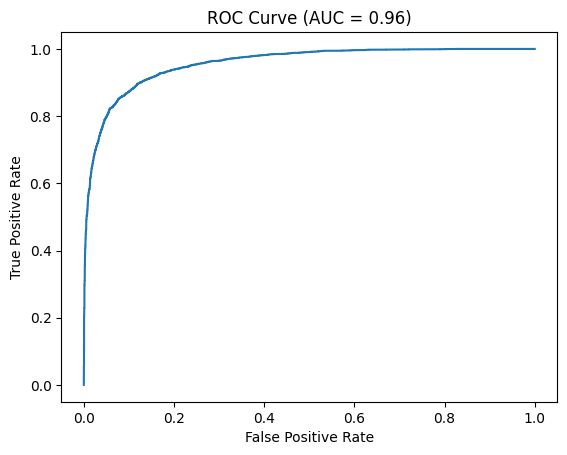

LSTM Model Results
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Confusion Matrix:
 [[4501  460]
 [ 689 4350]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89      4961
           1       0.90      0.86      0.88      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



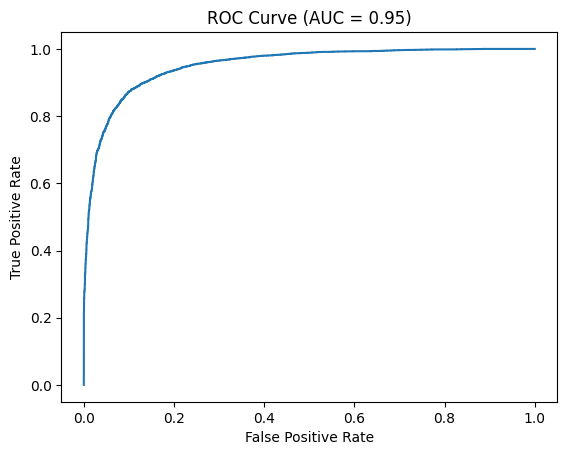

GRU Model Results
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Confusion Matrix:
 [[4404  557]
 [ 594 4445]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88      4961
           1       0.89      0.88      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



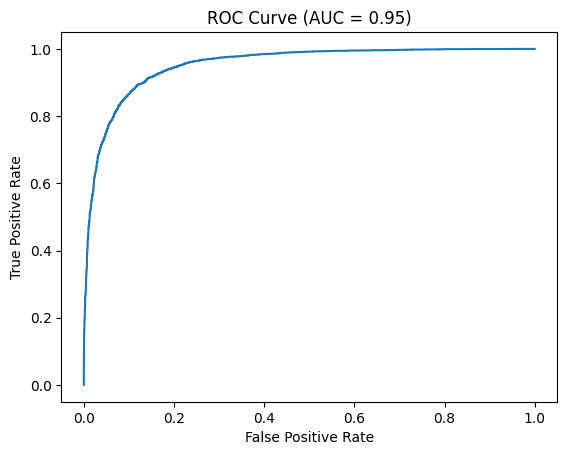

In [11]:
print("Dense Model Results")
evaluate_model(model_dense, X_test_pad, y_test)

print("LSTM Model Results")
evaluate_model(model_lstm, X_test_pad, y_test)

print("GRU Model Results")
evaluate_model(model_gru, X_test_pad, y_test)

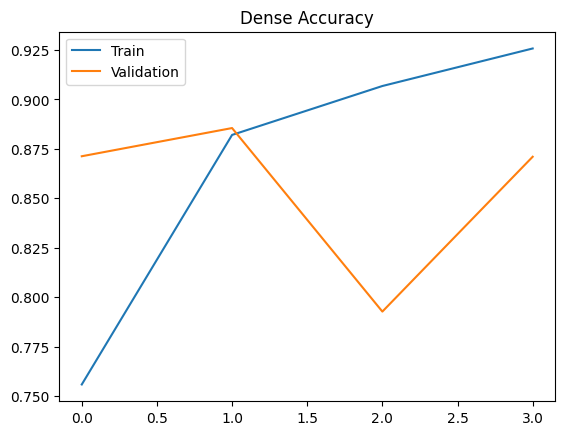

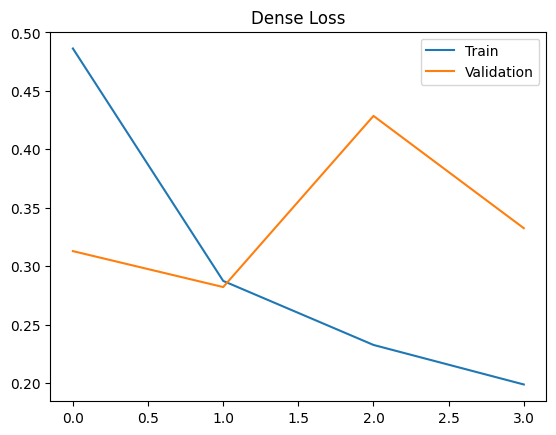

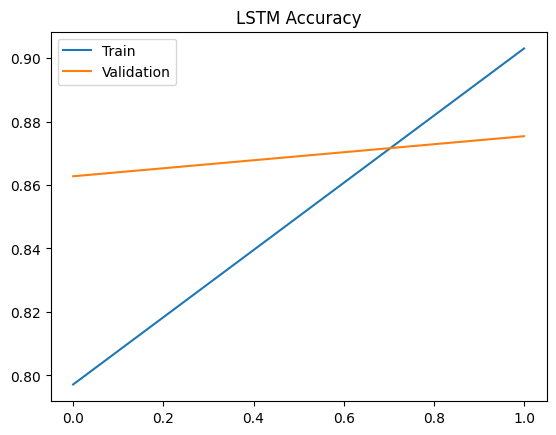

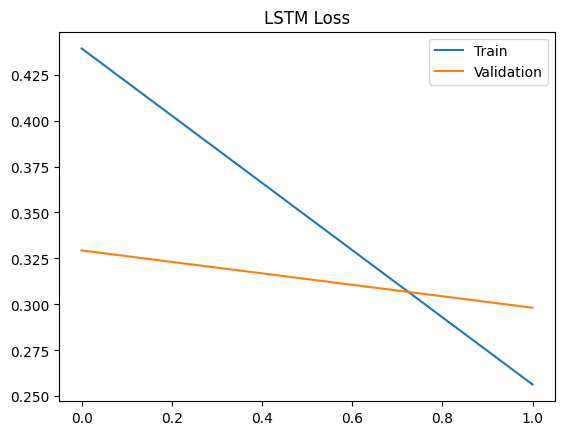

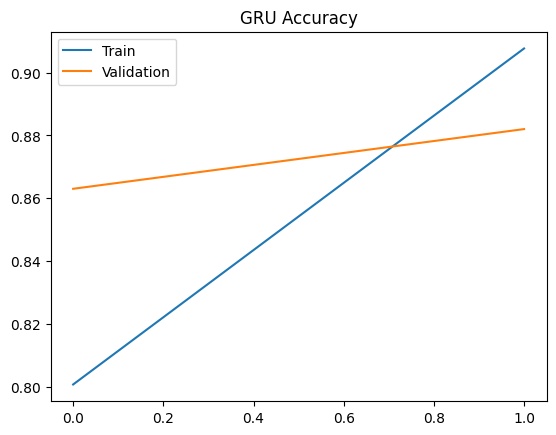

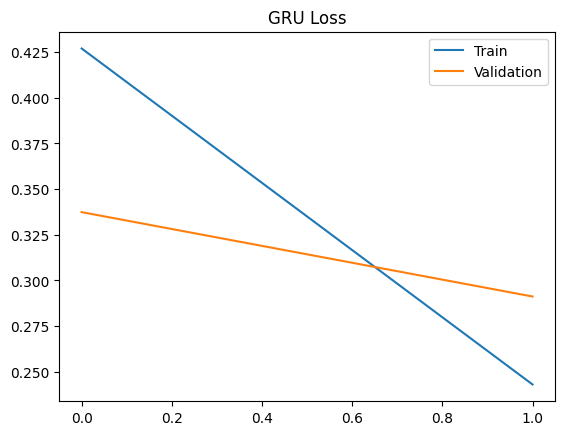

In [12]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + ' Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + ' Loss')
    plt.legend(['Train', 'Validation'])
    plt.show()

plot_history(history_dense, "Dense")
plot_history(history_lstm, "LSTM")
plot_history(history_gru, "GRU")

In [13]:
dense_acc = model_dense.evaluate(X_test_pad, y_test)[1]
lstm_acc = model_lstm.evaluate(X_test_pad, y_test)[1]
gru_acc = model_gru.evaluate(X_test_pad, y_test)[1]

print("Dense Accuracy:", dense_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy:", gru_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Precision: 0.8258 - Recall: 0.9387 - accuracy: 0.8693 - loss: 0.3210
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - Precision: 0.9044 - Recall: 0.8633 - accuracy: 0.8851 - loss: 0.2822
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - Precision: 0.8886 - Recall: 0.8821 - accuracy: 0.8849 - loss: 0.2794
Dense Accuracy: 0.8693000078201294
LSTM Accuracy: 0.8851000070571899
GRU Accuracy: 0.8848999738693237


In [14]:
def predict_sentiment(text, model):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)
    pred = model.predict(padded)[0][0]

    return "Positive" if pred > 0.5 else "Negative"

print(predict_sentiment("This movie was amazing!", model_lstm))
print(predict_sentiment("Worst movie ever", model_lstm))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Negative
